# Telecom Customer Analytics Project
## Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
field_Description = pd.read_excel("Field Descriptions.xlsx")
telecom_data = pd.read_excel("telecom_data_sample.xlsx")

field_Description.head()
telecom_data.head()


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770,2019-04-25 14:35:31,662,1823652,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611,2501332,8198936,9656251,278082303,14344150,171744450,8814393,36749741,308879636
1,13114483482878900224,2019-04-09 13:04:04,235,2019-04-25 08:15:48,606,1365104,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395,19111729,18338413,17227132,608750074,1170709,526904238,15055145,53800391,653384965
2,13114483484080500736,2019-04-09 17:42:11,1,2019-04-25 11:58:13,652,1361762,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661,14699576,17587794,6163408,229584621,395630,410692588,4215763,27883638,279807335
3,13114483485442799616,2019-04-10 00:31:25,486,2019-04-25 07:36:35,171,1321509,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122,15146643,13994646,1097942,799538153,10849722,749039933,12797283,43324218,846028530
4,13114483499480700928,2019-04-12 20:10:23,565,2019-04-25 10:40:32,954,1089009,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380,18962873,17124581,415218,527707248,3529801,550709500,13910322,38542814,569138589


## Step 2: Understanding the Dataset


In [2]:
telecom_data.shape
telecom_data.info()
telecom_data.isnull().sum().sort_values(ascending=False)



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Bearer Id                                 10000 non-null  object        
 1   Start                                     10000 non-null  datetime64[us]
 2   Start ms                                  10000 non-null  int64         
 3   End                                       10000 non-null  datetime64[us]
 4   End ms                                    10000 non-null  int64         
 5   Dur. (ms)                                 10000 non-null  int64         
 6   IMSI                                      9955 non-null   float64       
 7   MSISDN/Number                             9914 non-null   float64       
 8   IMEI                                      9955 non-null   float64       
 9   Last Location Name                      

Nb of sec with 37500B < Vol UL              7809
Nb of sec with 6250B < Vol UL < 37500B      5802
Nb of sec with 125000B < Vol DL             4373
TCP UL Retrans. Vol (Bytes)                 4356
Nb of sec with 31250B < Vol DL < 125000B    4032
Nb of sec with 1250B < Vol UL < 6250B       3982
Nb of sec with 6250B < Vol DL < 31250B      3548
TCP DL Retrans. Vol (Bytes)                 3524
HTTP UL (Bytes)                             2904
HTTP DL (Bytes)                             2858
Avg RTT DL (ms)                              746
Avg RTT UL (ms)                              743
MSISDN/Number                                 86
Last Location Name                            81
Nb of sec with Vol UL < 1250B                 79
UL TP < 10 Kbps (%)                           79
10 Kbps < UL TP < 50 Kbps (%)                 79
UL TP > 300 Kbps (%)                          79
50 Kbps < UL TP < 300 Kbps (%)                79
DL TP > 1 Mbps (%)                            71
50 Kbps < DL TP < 25

## Step 3: Data Cleaning


In [3]:
# checking the duplicates 
telecom_data.duplicated().sum()

np.int64(0)

### Interpretation

There are no duplicate records in the telecom dataset. Therefore, no duplicate rows need to be removed before further analysis.


### 3.1 Check Data Types

In [4]:
telecom_data.dtypes

Bearer Id                                           object
Start                                       datetime64[us]
Start ms                                             int64
End                                         datetime64[us]
End ms                                               int64
Dur. (ms)                                            int64
IMSI                                               float64
MSISDN/Number                                      float64
IMEI                                               float64
Last Location Name                                  object
Avg RTT DL (ms)                                    float64
Avg RTT UL (ms)                                    float64
Avg Bearer TP DL (kbps)                              int64
Avg Bearer TP UL (kbps)                              int64
TCP DL Retrans. Vol (Bytes)                        float64
TCP UL Retrans. Vol (Bytes)                        float64
DL TP < 50 Kbps (%)                                float

### Interpretation

The dataset contains three main data types:
- **float64**: Numerical variables such as download, upload, duration, and throughput.
- **object/string**: Categorical variables such as handset manufacturer and handset type.
- **datetime**: Date and time variables such as Start and End.

Understanding the data types helps us apply the appropriate data cleaning techniques to each type of column.

### 3.2 Create a Backup Copy of the Dataset

In [5]:
telecom_clean = telecom_data.copy()


A copy of the original dataset is created before cleaning so that the original data remains unchanged. This allows us to return to the raw dataset if needed.

### 3.3 Identifying the numerical columns


In [6]:
# Identifying the numerical columns

numeric_columns = telecom_clean.select_dtypes(include=['float64', 'int64']).columns

numeric_columns

Index(['Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)',
       'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)',
       'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)',
       '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)',
       'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)',
       '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)',
       'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Social Media DL (

### Interpretation

The numeric columns in the dataset have been identified successfully. These columns will be used to replace missing values with the mean, ensuring that only numerical features are modified while text and datetime columns remain unchanged.

###  3.4 Replace Missing Values with Mean

In [7]:
# Replace Missing Values with Mean
telecom_clean[numeric_columns] = telecom_clean[numeric_columns].fillna(
    telecom_clean[numeric_columns].mean() 
)



### Verify that the missing values were filled 

In [8]:
telecom_clean.isnull().sum().sort_values(ascending=False)


Last Location Name                          81
Handset Type                                45
Handset Manufacturer                        45
End                                          0
End ms                                       0
Start                                        0
Bearer Id                                    0
IMSI                                         0
MSISDN/Number                                0
IMEI                                         0
Avg RTT DL (ms)                              0
Avg RTT UL (ms)                              0
Avg Bearer TP DL (kbps)                      0
Avg Bearer TP UL (kbps)                      0
TCP DL Retrans. Vol (Bytes)                  0
TCP UL Retrans. Vol (Bytes)                  0
DL TP < 50 Kbps (%)                          0
50 Kbps < DL TP < 250 Kbps (%)               0
250 Kbps < DL TP < 1 Mbps (%)                0
DL TP > 1 Mbps (%)                           0
UL TP < 10 Kbps (%)                          0
Dur. (ms)    

### Interpretation

The missing values in all numerical columns have been successfully replaced using the mean of their respective columns.

The remaining missing values belong to categorical (text) columns and datetime columns. These require different treatment because replacing text or dates with a numerical mean is not appropriate.

### Step 3.6: Replace Missing Values in Categorical Columns with Mode

In [9]:
categorical_columns = telecom_clean.select_dtypes(include=['object']).columns

categorical_columns

C:\Users\USER\AppData\Local\Temp\ipykernel_5604\3175511889.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = telecom_clean.select_dtypes(include=['object']).columns


Index(['Bearer Id', 'Last Location Name', 'Handset Manufacturer',
       'Handset Type'],
      dtype='str')

### Fill Missing Values with Mode

In [10]:
for column in categorical_columns:
    telecom_clean[column] = telecom_clean[column].fillna(
        telecom_clean[column].mode()[0]
    )

telecom_clean.isnull().sum().sort_values(ascending=False)

Bearer Id                                   0
Start                                       0
Start ms                                    0
End                                         0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### 3.7 Handle Missing Datetime Values

In [11]:
telecom_clean.dropna(subset=['Start', 'End'], inplace=True)
telecom_clean.isnull().sum().sort_values(ascending=False)


Bearer Id                                   0
Start                                       0
Start ms                                    0
End                                         0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### Data Cleaning Summary

The telecom dataset was cleaned using the following steps:

- Checked for duplicate records (no duplicates found).
- Identified data types of all columns.
- Created a backup copy of the original dataset.
- Replaced missing values in numerical columns using the mean.
- Replaced missing values in categorical columns using the mode.
- Removed rows containing missing datetime values.
- Verified that no missing values remained after cleaning.

The dataset is now clean and ready for Exploratory Data Analysis (EDA).

## 4: Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics

In [12]:
telecom_clean.describe()

,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,10000,10000.000000,10000,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,...,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,2019-04-24 06:49:39.346100,498.652400,2019-04-25 01:40:19.960800,497.978000,6.784005e+04,2.082017e+14,3.367591e+10,5.222416e+13,131.831316,20.167225,...,1.156697e+07,1.093792e+07,1.159491e+07,1.086662e+07,4.201976e+08,8.252164e+06,4.206466e+08,8.335074e+06,4.095209e+07,4.527532e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 23:00:04,0.000000,2.295800e+04,2.082001e+14,3.360107e+10,1.247901e+12,6.000000,0.000000,...,1.224000e+03,1.050000e+02,1.136000e+03,2.430000e+02,1.251100e+04,1.394000e+03,4.236660e+05,1.905000e+03,6.243519e+06,7.114041e+06
25%,2019-04-24 02:44:04.750000,250.000000,2019-04-25 00:22:23.750000,251.000000,4.158475e+04,2.082014e+14,3.365817e+10,3.552141e+13,38.000000,4.000000,...,5.669677e+06,5.505214e+06,5.695370e+06,5.381031e+06,2.115701e+08,4.063424e+06,2.089014e+08,4.189338e+06,3.288391e+07,2.459591e+08
50%,2019-04-24 09:13:03,497.000000,2019-04-25 01:18:16.500000,498.000000,5.775800e+04,2.082015e+14,3.366414e+10,3.575751e+13,55.000000,9.000000,...,1.152480e+07,1.078695e+07,1.155351e+07,1.073990e+07,4.204656e+08,8.229242e+06,4.242242e+08,8.342401e+06,4.083175e+07,4.526578e+08
75%,2019-04-24 13:55:15,747.250000,2019-04-25 02:41:31.500000,743.000000,8.639900e+04,2.082018e+14,3.368290e+10,8.637690e+13,104.000000,20.167225,...,1.750616e+07,1.643212e+07,1.734177e+07,1.627824e+07,6.317820e+08,1.241018e+07,6.289928e+08,1.246929e+07,4.895531e+07,6.633708e+08
max,2019-04-24 16:41:00,999.000000,2019-04-25 23:57:10,999.000000,1.823652e+06,2.082099e+14,3.378998e+10,9.900120e+13,54847.000000,5279.000000,...,2.325829e+07,2.201196e+07,2.325798e+07,2.200974e+07,8.434419e+08,1.655607e+07,8.433458e+08,1.655667e+07,7.391670e+07,8.964337e+08
std,NaN,288.279077,NaN,285.872685,6.188302e+04,1.309472e+09,4.451077e+07,2.418055e+13,738.071636,79.103459,...,6.758998e+06,6.314766e+06,6.696971e+06,6.320848e+06,2.435583e+08,4.814455e+06,2.413300e+08,4.772618e+06,1.123271e+07,2.436977e+08


### Interpretation

The summary statistics provide an overview of the numerical variables in the telecom dataset.

- The dataset contains **150,000 cleaned observations**.
- The mean values represent the average customer usage for each numerical variable.
- The standard deviation indicates considerable variability in customer behavior.
- The minimum and maximum values show that some variables contain extremely large values, suggesting possible outliers.
- The quartiles (25%, 50%, and 75%) describe the distribution of the data and provide insight into the spread of customer usage.
- Overall, the dataset is ready for visualization and deeper exploratory analysis.

## 4.2 Distribution of Session Duration

A histogram is used to visualize the distribution of session duration. It helps us understand how frequently different session durations occur and whether the data is normally distributed or skewed.

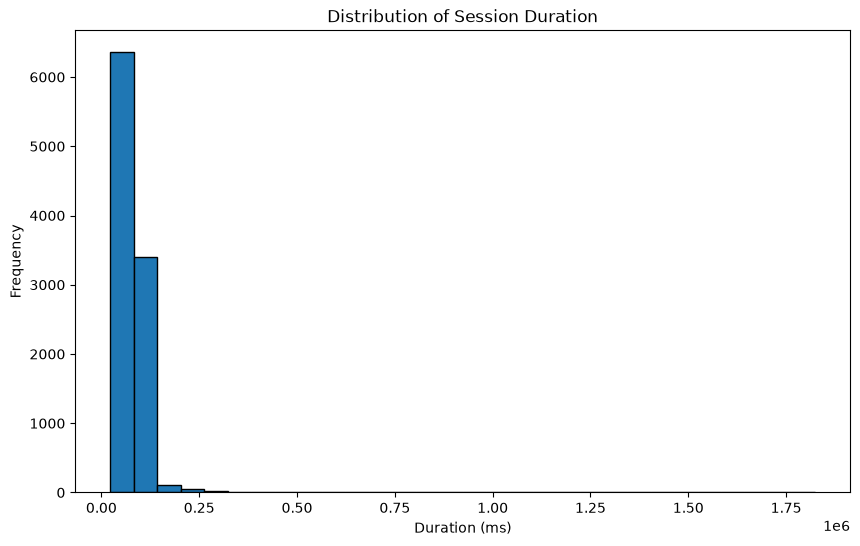

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(telecom_clean['Dur. (ms)'], bins=30, edgecolor='black')

plt.title('Distribution of Session Duration')
plt.xlabel('Duration (ms)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of customer session duration.

- Most telecom sessions are concentrated within shorter durations.
- The distribution is positively (right) skewed, indicating that a small number of customers have significantly longer session durations.
- A few extreme values are visible, suggesting the presence of heavy users or outliers.
- The data is not normally distributed, which is common in telecom usage datasets.


## 4.3 Box Plot of Session Duration

A box plot is used to identify the spread of the data and detect potential outliers. It summarizes the distribution using the median, quartiles, and extreme values.

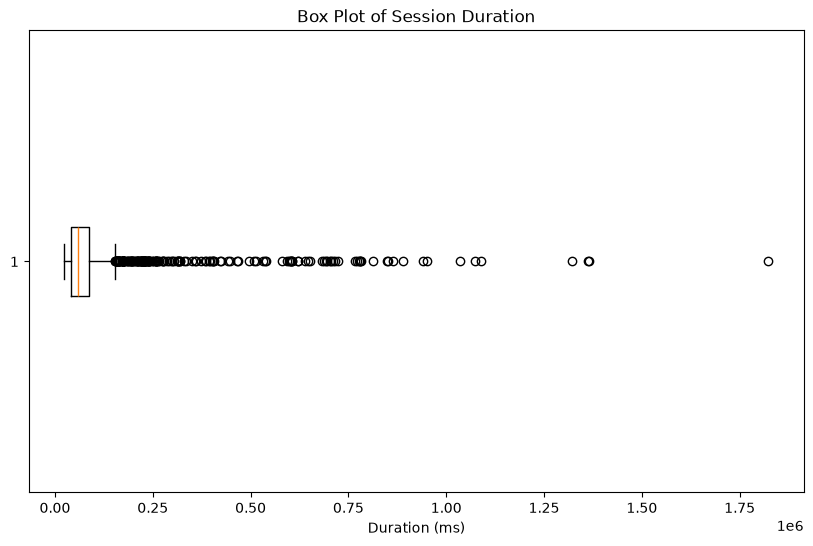

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(telecom_clean['Dur. (ms)'], orientation='horizontal') 

plt.title('Box Plot of Session Duration')
plt.xlabel('Duration (ms)')

plt.show()

### Interpretation

The box plot indicates that session duration contains a large number of outliers. Most customer sessions are concentrated within a relatively small range, while a few sessions have exceptionally long durations. This suggests that the distribution is positively skewed and that some users spend significantly more time on the network than the average customer. 

### 4.4: Histogram of Total Download (Bytes)

### Why are we plotting this?

A histogram of Total Download (Bytes) helps us understand how internet download usage is distributed among customers. It shows whether most customers download similar amounts of data or whether a few customers consume significantly higher amounts.

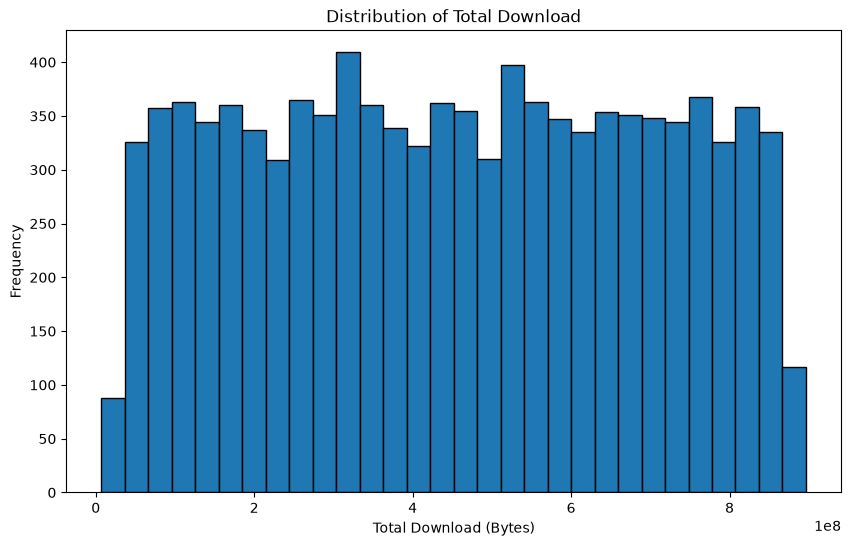

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(telecom_clean['Total DL (Bytes)'],
         bins=30,
         edgecolor='black')

plt.title("Distribution of Total Download")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The histogram shows that Total Download (Bytes) is fairly evenly distributed across the dataset. Unlike session duration, download usage does not exhibit a strong positive skew. Customers are spread across different download usage levels, indicating a wide variety of internet consumption patterns.

## 4.5 Box Plot of Total Download


A box plot summarizes the distribution of Total Download (Bytes) and helps identify potential outliers among customers with unusually high or low download usage.

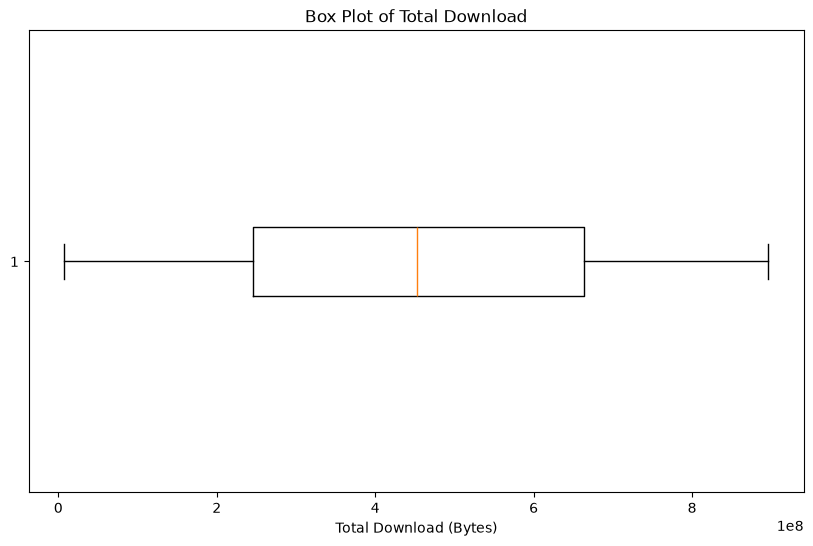

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(
    telecom_clean['Total DL (Bytes)'],
    orientation='horizontal'
)

plt.title("Box Plot of Total Download")
plt.xlabel("Total Download (Bytes)")

plt.show()

### Interpretation

The box plot shows that Total Download (Bytes) is fairly evenly distributed with no significant outliers. The median is positioned near the center of the box, indicating a balanced distribution. The spread of the data suggests that customers have a wide range of download usage, but there are no unusually extreme download values.

### 4.4 Correlation Heatmap 


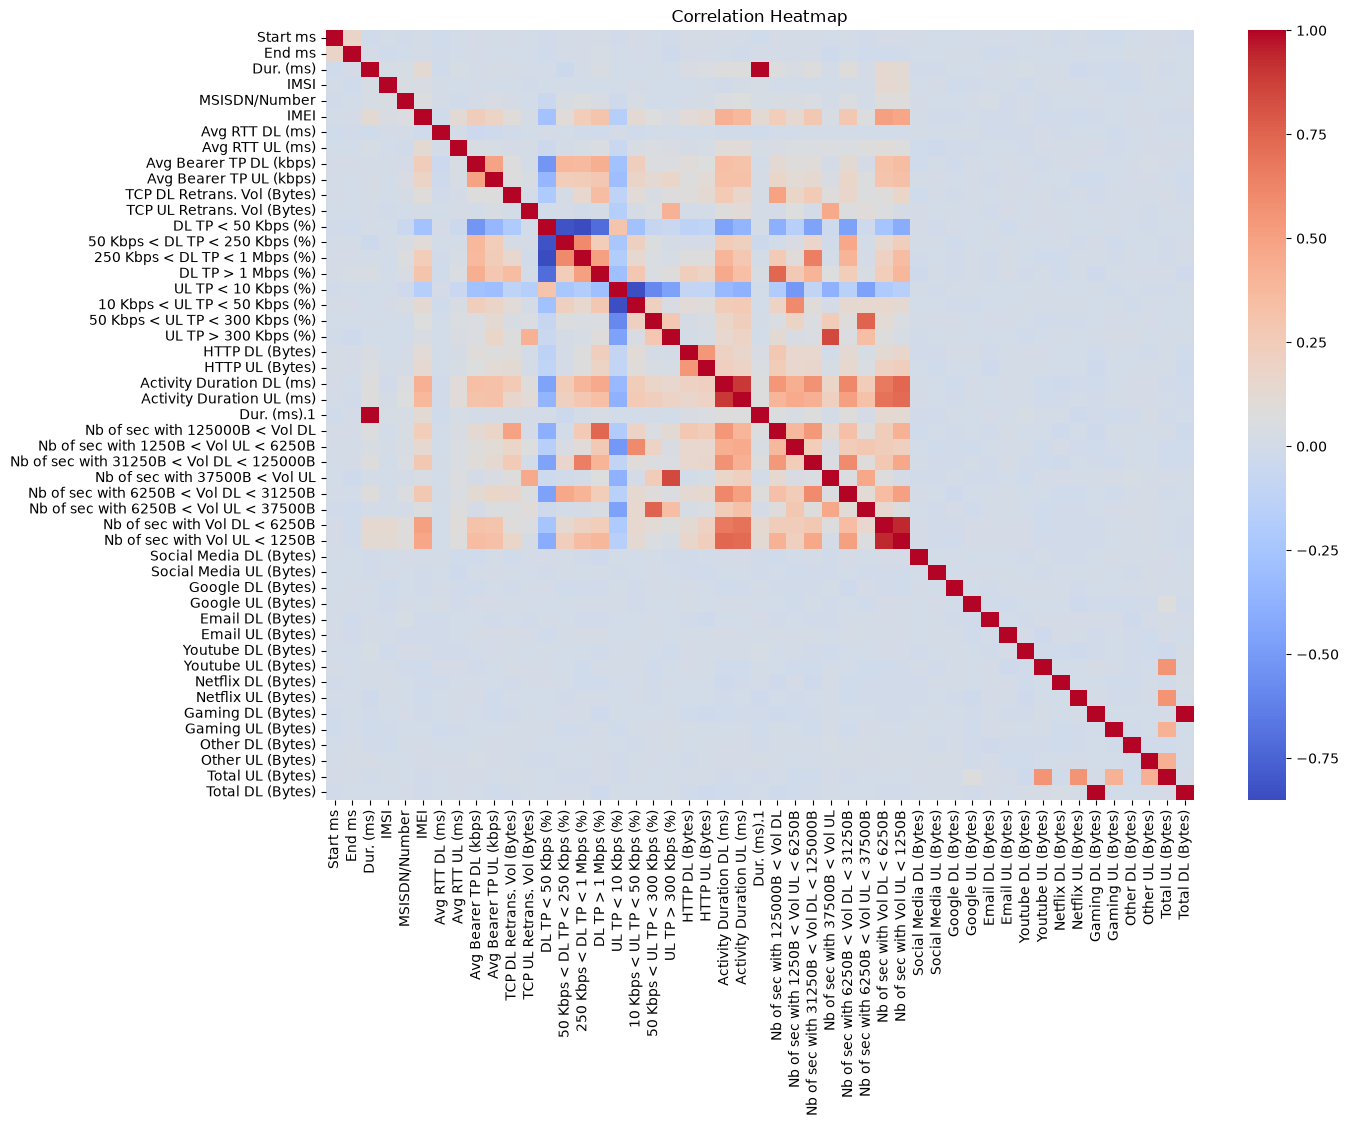

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    telecom_clean.select_dtypes(include=['float64','int64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- The heatmap displays the correlation between all numerical variables.
- Dark red colors indicate a strong positive correlation.
- Dark blue colors indicate a strong negative correlation.
- Light colors indicate little or no correlation.
- Most variables show weak to moderate correlations, while a few download and upload-related variables have stronger positive relationships.
- The heatmap helps identify important features for further analysis and predictive modeling.

## 4.5 Scatter Plot: Total Download vs Total Upload

A scatter plot is used to visualize the relationship between two numerical variables. It helps identify positive or negative correlations, clusters, and unusual observations.

Here, we compare Total Download (Bytes) with Total Upload (Bytes) to understand whether customers with higher download usage also tend to have higher upload usage.

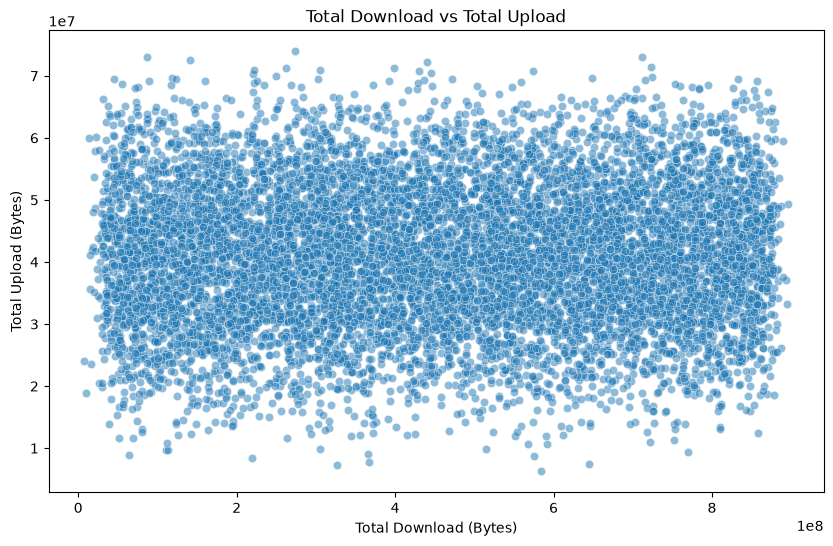

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=telecom_clean['Total DL (Bytes)'],
    y=telecom_clean['Total UL (Bytes)'],
    alpha=0.5
)

plt.title("Total Download vs Total Upload")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Total Upload (Bytes)")

plt.show()

### Interpretation:

The scatter plot compares Total Download (Bytes) and Total Upload (Bytes).
The data points are widely scattered across the graph.
There is no clear linear relationship between download and upload traffic.
This suggests that customers with higher download usage do not necessarily have higher upload usage.
Further statistical analysis (such as the correlation coefficient) would be needed to measure the strength of the relationship.

## 4.6 Top 3 Handset Manufacturers

In [21]:
# Find the top 3 handset manufacturers
top_manufacturers = telecom_clean['Handset Manufacturer'].value_counts().head(3)

top_manufacturers

Handset Manufacturer
Apple      3943
Huawei     3036
Samsung    2039
Name: count, dtype: int64

## 4.7 Top 10 Handset Manufacturers

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Huawei B528S-23A'),
  Text(1, 0, 'Apple iPhone 6 (A1586)'),
  Text(2, 0, 'Apple iPhone 6S (A1688)'),
  Text(3, 0, 'Apple iPhone 7 (A1778)'),
  Text(4, 0, 'undefined'),
  Text(5, 0, 'Apple iPhone 8 (A1905)'),
  Text(6, 0, 'Apple iPhone Se (A1723)'),
  Text(7, 0, 'Apple iPhone Xr (A2105)'),
  Text(8, 0, 'Apple iPhone X (A1901)'),
  Text(9, 0, 'Samsung Galaxy S8 (Sm-G950F)')])

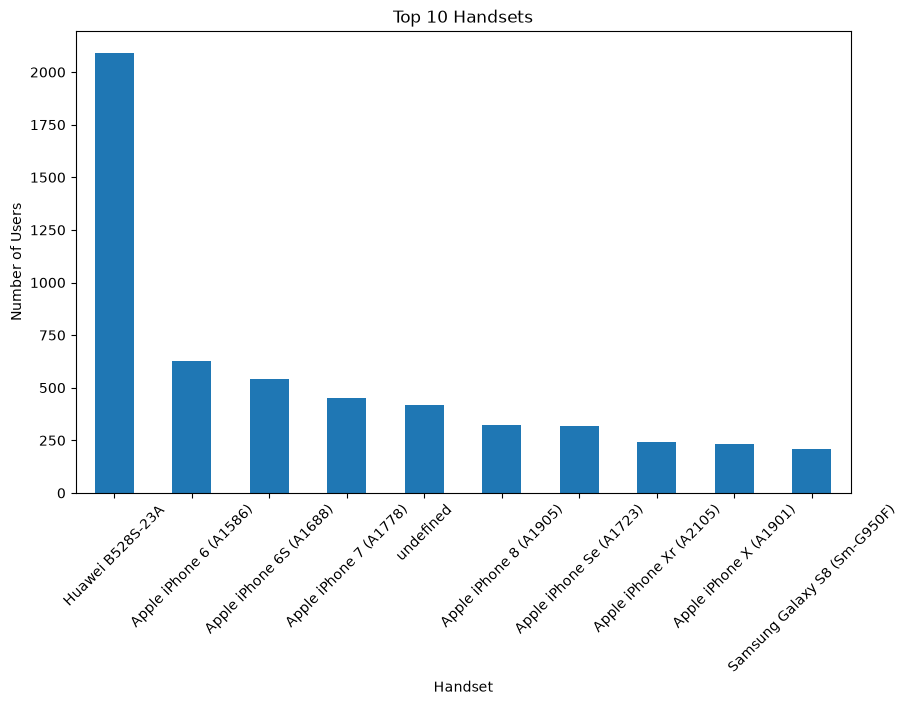

In [23]:
import matplotlib.pyplot as plt

top_handsets = telecom_clean['Handset Type'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_handsets.plot(kind='bar')

plt.title('Top 10 Handsets')
plt.xlabel('Handset')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)


### Interpretation:

The analysis identifies the ten most frequently used handset models among customers. Huawei B528S-23A is the most widely used handset, followed by several Apple iPhone models. This indicates that customer device usage is concentrated among a relatively small number of handset models. These insights can help the telecom company optimize network compatibility, customer support, and targeted marketing for the most commonly used devices.

##  4.8 Top 5 Handsets per Top 3 Manufacturers

In [25]:
# Top 5 handsets for each of the top 3 manufacturers

top_manufacturers = telecom_clean['Handset Manufacturer'].value_counts().head(3).index

for manufacturer in top_manufacturers:
    top_handsets = (
        telecom_clean[telecom_clean['Handset Manufacturer'] == manufacturer]
        ['Handset Type']
        .value_counts()
        .head(5)
    )
    
    print(f"\nTop 5 Handsets for {manufacturer}:")
    print(top_handsets)


Top 5 Handsets for Apple:
Handset Type
Apple iPhone 6 (A1586)     628
Apple iPhone 6S (A1688)    541
Apple iPhone 7 (A1778)     449
Apple iPhone 8 (A1905)     325
Apple iPhone Se (A1723)    319
Name: count, dtype: int64

Top 5 Handsets for Huawei:
Handset Type
Huawei B528S-23A                  2046
Huawei E5180                       209
Huawei P20 Lite Huawei Nova 3E     116
Huawei P20                          82
Huawei Y6 2018                      61
Name: count, dtype: int64

Top 5 Handsets for Samsung:
Handset Type
Samsung Galaxy S8 (Sm-G950F)    211
Samsung Galaxy A5 Sm-A520F      163
Samsung Galaxy S7 (Sm-G930X)    150
Samsung Galaxy J3 (Sm-J330)     140
Samsung Galaxy J5 (Sm-J530)     125
Name: count, dtype: int64


### Interpretation:
The analysis identifies the top 5 most frequently used handset models for each of the top 3 handset manufacturers: Apple, Huawei, and Samsung.

For Apple, the most frequently used model is Apple iPhone 6 (A1586), followed by iPhone 6S, iPhone 7, iPhone 8, and iPhone SE.
For Huawei, Huawei B528S-23A is by far the most frequently used model, followed by Huawei E5180, Huawei P20 Lite Huawei Nova 3E, Huawei P20, and Huawei Y6 2018.
For Samsung, Samsung Galaxy S8 (SM-G950F) is the most frequently used model among the top five, followed by Galaxy A5, Galaxy S7, Galaxy J3, and Galaxy J5.

These results show which specific handset models are most common among customers using the three leading manufacturers. This information can help the telecom company with network compatibility, device-specific customer support, and targeted marketing.

# 5. Application Usage Analysis

This section analyzes the total network traffic generated by different applications such as Social Media, Google, Email, YouTube, Netflix, Gaming, and Other services. The objective is to identify which applications consume the highest amount of network resources.

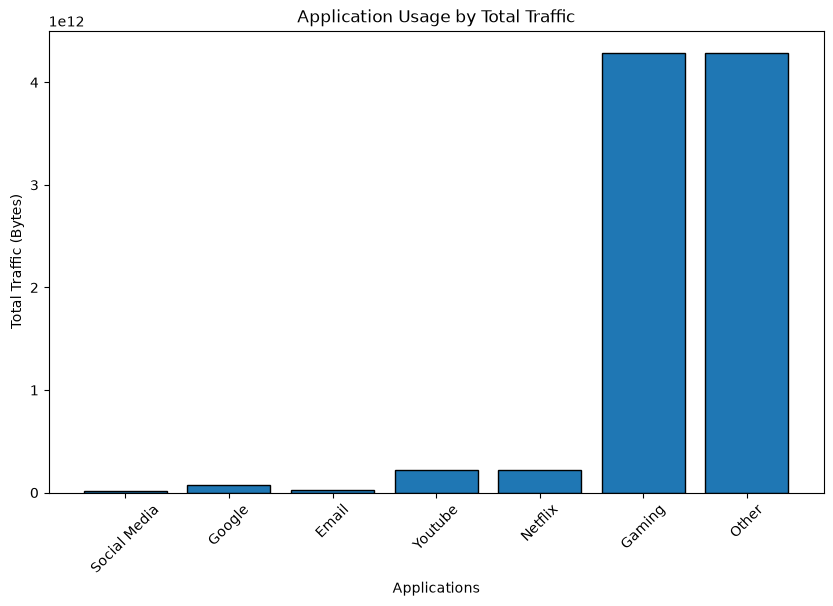

In [26]:
applications = {
    'Social Media': telecom_clean['Social Media DL (Bytes)'].sum() + telecom_clean['Social Media UL (Bytes)'].sum(),
    'Google': telecom_clean['Google DL (Bytes)'].sum() + telecom_clean['Google UL (Bytes)'].sum(),
    'Email': telecom_clean['Email DL (Bytes)'].sum() + telecom_clean['Email UL (Bytes)'].sum(),
    'Youtube': telecom_clean['Youtube DL (Bytes)'].sum() + telecom_clean['Youtube UL (Bytes)'].sum(),
    'Netflix': telecom_clean['Netflix DL (Bytes)'].sum() + telecom_clean['Netflix UL (Bytes)'].sum(),
    'Gaming': telecom_clean['Gaming DL (Bytes)'].sum() + telecom_clean['Gaming UL (Bytes)'].sum(),
    'Other': telecom_clean['Other DL (Bytes)'].sum() + telecom_clean['Other UL (Bytes)'].sum()
}

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    applications.keys(),
    applications.values(),
    edgecolor='black'
)

plt.title("Application Usage by Total Traffic")
plt.xlabel("Applications")
plt.ylabel("Total Traffic (Bytes)")
plt.xticks(rotation=45)

plt.show()

### Interpretation:
The chart shows the total network traffic generated by different applications. Gaming and Other applications generate the highest total traffic, followed by YouTube and Netflix. Google, Social Media, and Email contribute comparatively less network traffic. This indicates that a large proportion of the telecom network traffic is generated by Gaming and Other services.




Business Insight:

The telecom company should closely monitor network demand from Gaming and Other services, as they account for the largest share of total traffic. Understanding application usage patterns can help optimize bandwidth allocation, improve network performance, and enhance customer experience.



Business Recommendation:

Monitor traffic trends for high-usage applications such as Gaming and Other services. The telecom company can optimize network capacity and infrastructure based on application demand to reduce potential congestion and maintain service quality.

# 6. Executive Summary
This Telecom Customer Analytics Project analyzed customer network usage, handset information, and application traffic using Python. The dataset was cleaned by handling missing values and preparing numerical and categorical variables for analysis.

Exploratory Data Analysis (EDA) was performed using summary statistics, histograms, boxplots, correlation analysis, scatter plots, and bar charts to understand customer usage patterns.

The analysis found that Apple, Huawei, and Samsung are the most widely used handset manufacturers, with Huawei B528S-23A being the most commonly used handset model. Gaming and Other applications generate the highest total network traffic, while Total Download and Total Upload do not show a clear strong linear relationship.

These findings can help the telecom company improve network planning, bandwidth allocation, customer support, and device-specific services.

# 7. Key Findings

• The dataset contained missing values that were successfully handled using mean and mode imputation.

• Most numerical variables showed skewed distributions with several outliers.

• The correlation heatmap indicated only a few strong relationships between network-related variables.

• There is no strong relationship between Total Download and Total Upload traffic.

• Apple, Huawei, and Samsung are the most widely used handset manufacturers.

• Huawei B528S-23A is the most commonly used handset model.

• Gaming and Other applications generate the highest amount of network traffic.

• These insights can help improve bandwidth allocation, customer service, and infrastructure planning.

# 8. Final Business Recommendations

• Increase network capacity for high-traffic applications such as Gaming and Other.

• Focus customer support and software optimization on the most commonly used handset manufacturers and models.

• Continuously monitor application traffic trends to improve Quality of Service (QoS).

• Optimize network resources during peak traffic hours to reduce congestion.

• Improve data collection processes to minimize missing or undefined handset information.

• Use customer usage patterns for future marketing campaigns and service planning.

# 9. Conclusion

The Telecom Customer Analytics Project successfully explored customer usage behavior, device popularity, and application traffic using Python.

The project demonstrates the complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, and business insights.

The findings can support telecom companies in making data-driven decisions related to network optimization, customer experience, and strategic planning.
